# Independent component analysis

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from sklearn.decomposition import FastICA

## Exercise 1: Blind source separation using FastICA
Imagine three singers (sources) that each generate a sound $s_{i}(t)$ over time $t$. Three microphones surround the singers and record the sound $x_{j}(t)$. Given the observations of the three microphones $x_{j}(t), j=\{1,2,3\}$, we want to compute a reconstruction of the contribution of each singer $s_{i,rec}(t)$ using an ICA model.

**Note:** In the following code, the true sources $S_{true}$ as well as the mixing matrix $A$ are given to generate the observations $X$. In a real-world scenario, this would of course not be the case. Instead, you want to reconstruct the independent sources $S_{rec}$ and the estimated mixing matrix $\hat A$. This means we **ONLY** have access to our observations $X$.

1. Train an ICA (`FastICA()`) model to reconstruct $s_{i,rec}(t)$ of each singer. 
1. Visualize the observations $x_{j}(t)$ of every microphone, the reconstructed source signals $s_{i,rec}(t)$ and the true sources for all three components $s_{i,true}(t)$. Use the function `visualize_data()` as you need to do such plots a few times within this exercise;
1. Compare the time series of the reconstructed sources with the true sources in terms of their order and sign. What do you observe?
1. Plot histograms of the estimated sources;
1. Verify the distribution of the estimated independent components. Which types of distributions do you expect the ICA to return?

In [2]:
def visualize_data(models, names):
    '''plot figure with subplot for each specified model, 
    in each subplot all three components are shown
    Input: list 'models', 'names' 
    Usage: visualize_data(models = [X, S_true], names = ['observations X', 'true sources'])'''
    colors = ['red', 'skyblue', 'orange']
    plt.figure(figsize=(12, 8))
    for i, (model, name) in enumerate(zip(models, names), 1):
        plt.subplot(len(names), 1, i)
        plt.title(name, fontsize=15)
        for sig, color in zip(model.T, colors):
            plt.plot(sig + i * 2 * max(sig), color=color)
        plt.xlabel("samples")
        plt.ylabel("amplitude")
    plt.subplots_adjust(0.09, 0.04, 0.94, 0.94, 0.26, 0.46)

In [3]:
# Generate sample data
np.random.seed(35)
N = 2000
time = np.linspace(0, 8, N)

# Singer 1: sinusoidal signal
s1 = np.sin(3 * time)  
# Singer 2: square signal
s2 = np.sign(np.sin(4 * time))
# Singer 3: saw tooth signal
s3 = signal.sawtooth(2 * np.pi * time)  

# Concatenate the true single sources and add noise 
S_true = np.c_[s1, s2, s3]
S_true += 0.5 * np.random.normal(size=S_true.shape)  

# Standardize the data
S_true /= S_true.std(axis=0) 

# Mix data
A = np.array([[1, 1, 1], [0.3, 2, 1.2], [1.5, 1.2, 2.4]])  # Mixing matrix
X = np.dot(S_true, A.T)

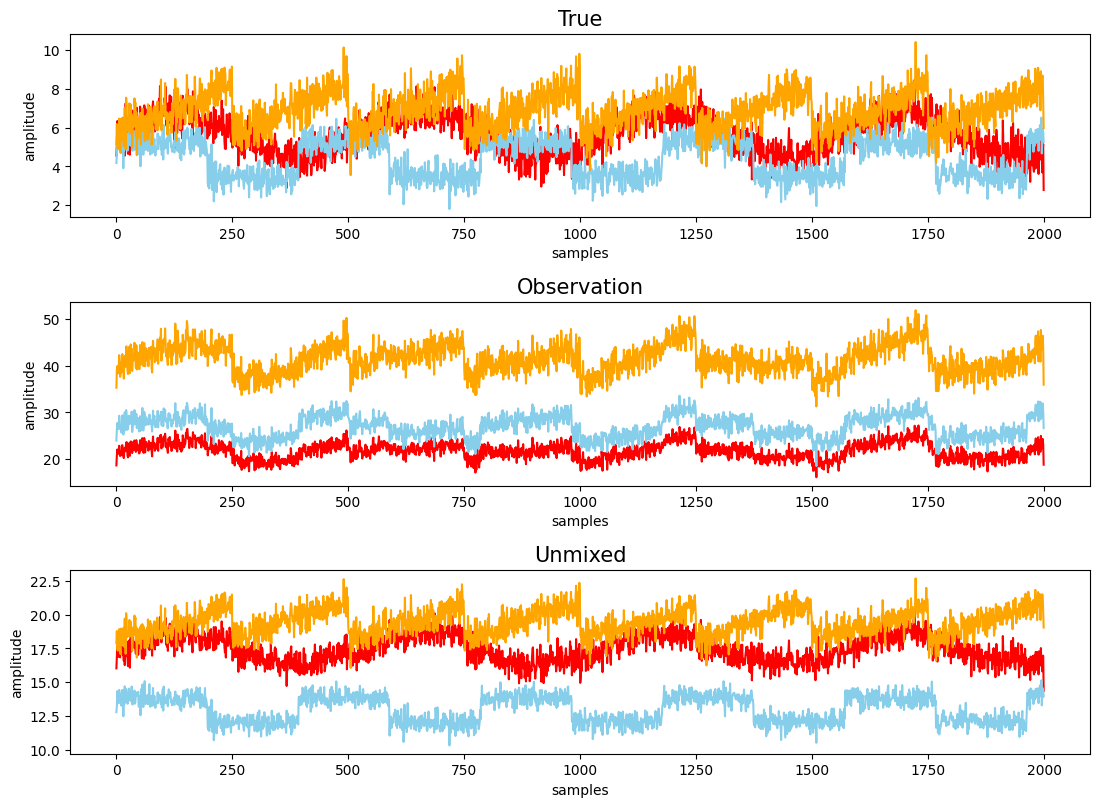

In [9]:
transformer = FastICA(n_components=3, random_state=42)
X_unmixed = transformer.fit_transform(X)
visualize_data([S_true, X, X_unmixed], ["True", "Observation", "Unmixed"])

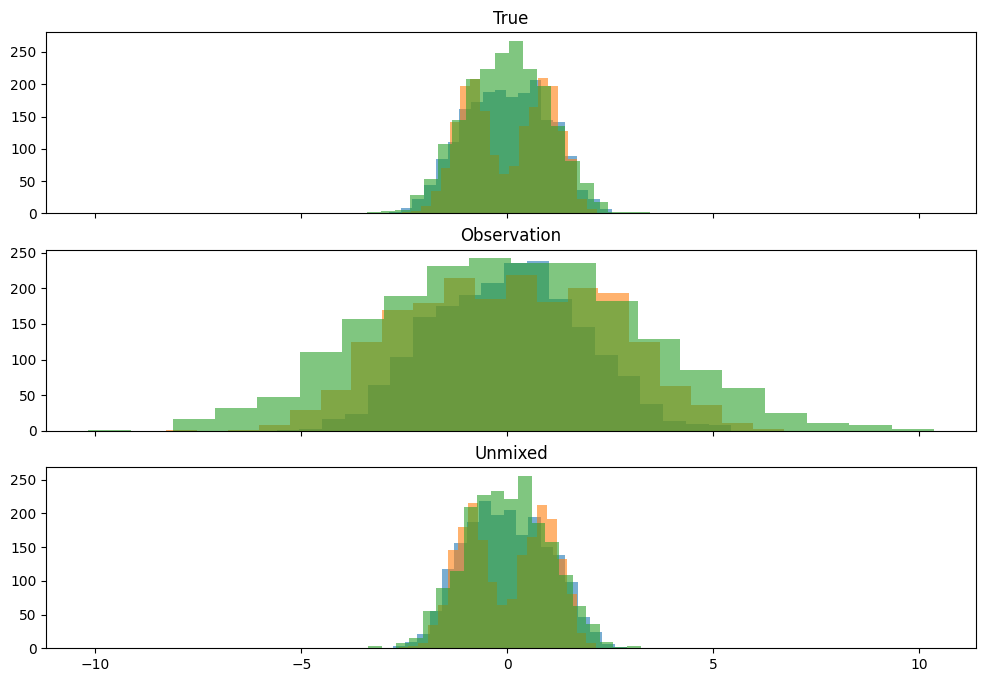

In [22]:
fig, ax = plt.subplots(3, figsize=(12, 8), sharex=True)

for i, (label, data) in enumerate([("True", S_true), ("Observation", X), ("Unmixed", X_unmixed)]):
    ax[i].set_title(label)
    
    for component in data.T:
        ax[i].hist(component, alpha=.6, bins=20)

## Exercise 2: Influence of data shuffling (across time)
1. Generate a time-shuffled version of the observations $X_{shuffled}$. **Hint:** You can use the `np.random.permutation()` function to generate a permutation of timesteps $\{1, 2, ..., T\}$, which can be used to rearrange your dataset along one axis;
1. Compute an ICA model on the modified recordings $X_{shuffled}$ and un-shuffle the reconstructed independent sources $S_{rec,shuffled}$ such that it has the same temporal order as $S_{true}$. **Hint:** You can use the `np.argsort()` function to invert the permutation you generated before;
1. Use the `visualize_data()` function to plot the reconstructed, unshuffled ICA-sources $S_{rec}$ and the true sources $S_{true}$;
1. Compare the reconstructed ICA-sources for the shuffled data and the non-shuffled data - can you give a reason for your observation?

**Note**: There are ICA variants that do take temporal information into account to improve blind source separation of time series. See __[1](https://ieeexplore.ieee.org/document/554307/)__ and __[2](https://link.springer.com/chapter/10.1007/978-1-4471-1599-1_103)__ 

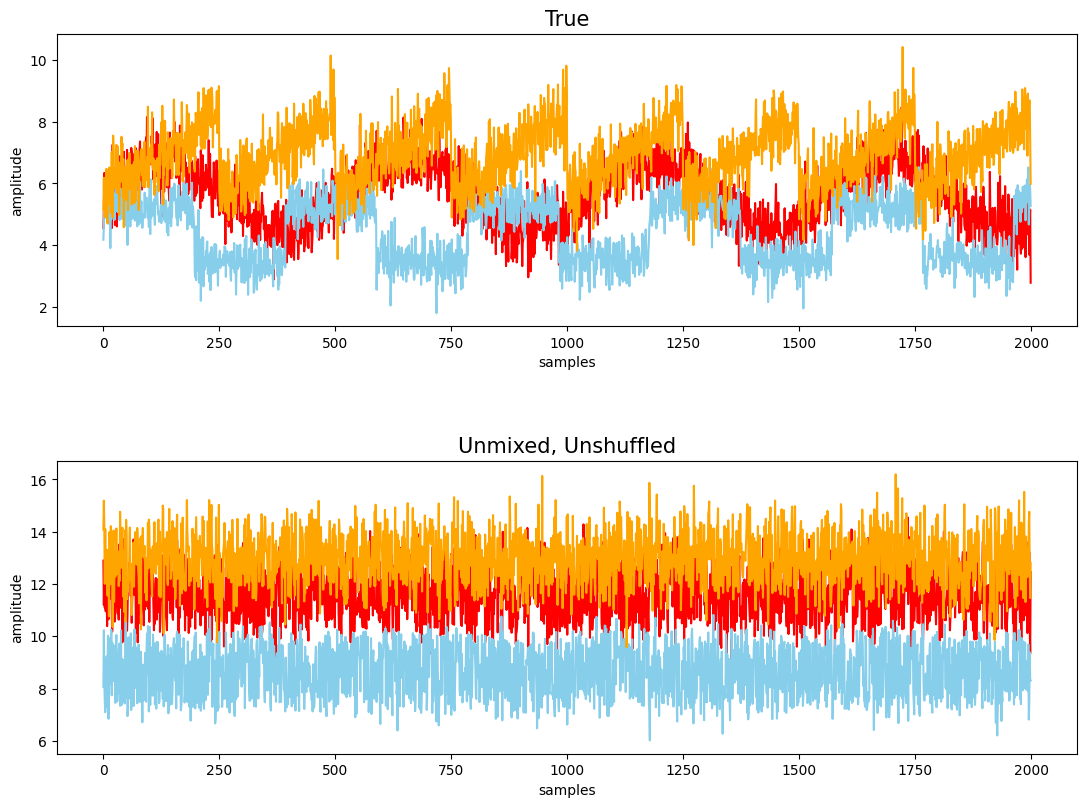

In [33]:
shuffle_idx = np.random.permutation(len(X))
X_shuffled = X[shuffle_idx]
transformer = FastICA(n_components=3, random_state=42)
X_shuffled_unmixed = transformer.fit_transform(X)

X_unshuffled_unmixed = X_shuffled_unmixed[np.argsort(shuffle_idx)]
visualize_data([S_true, X_unshuffled_unmixed], ["True", "Unmixed, Unshuffled"])

## Exercise 3: Remove (project out) ICA component(s) from your observations
We like to remove (also called projecting out) the contribution of two singers from the studio recordings $X$ such that only the contribution of singer 1 (sinusoidal waveform) remains. Therefore, you need to do the following steps:
1. Take the unmixing matrix $W=\hat A^{-1}$ of the component/s you want to keep and project the observation data $X$ to the source space $S_{est}$;
2. Use the estimated mixing matrix $\hat A$ of the component/s you want to keep and project the reconstructed sources $S_{est}$ back to the observation space $X_{clean}$;
3. Visualize the cleaned observations $X_{clean}$, the original observations $X$ as well as the reconstructed sources $S_{est}$.

**Hint:** When selecting the components you want to remove from the observations, it might help to iteratively look at the cleaned observations $X_{clean}$ to see the effect.

**Hint:** When multiplying two vectors, think about your input and output dimensions. What kind of operation is required? Think about the inner product versus the outer product of two vectors.

**Note**: This procedure, removing ICA components from the data, is a useful one to remove (mixed) features (sources) from your data. In EEG/BCI, such "sources" could, for instance, be eye blinks that have a clear spatial-temporal profile.

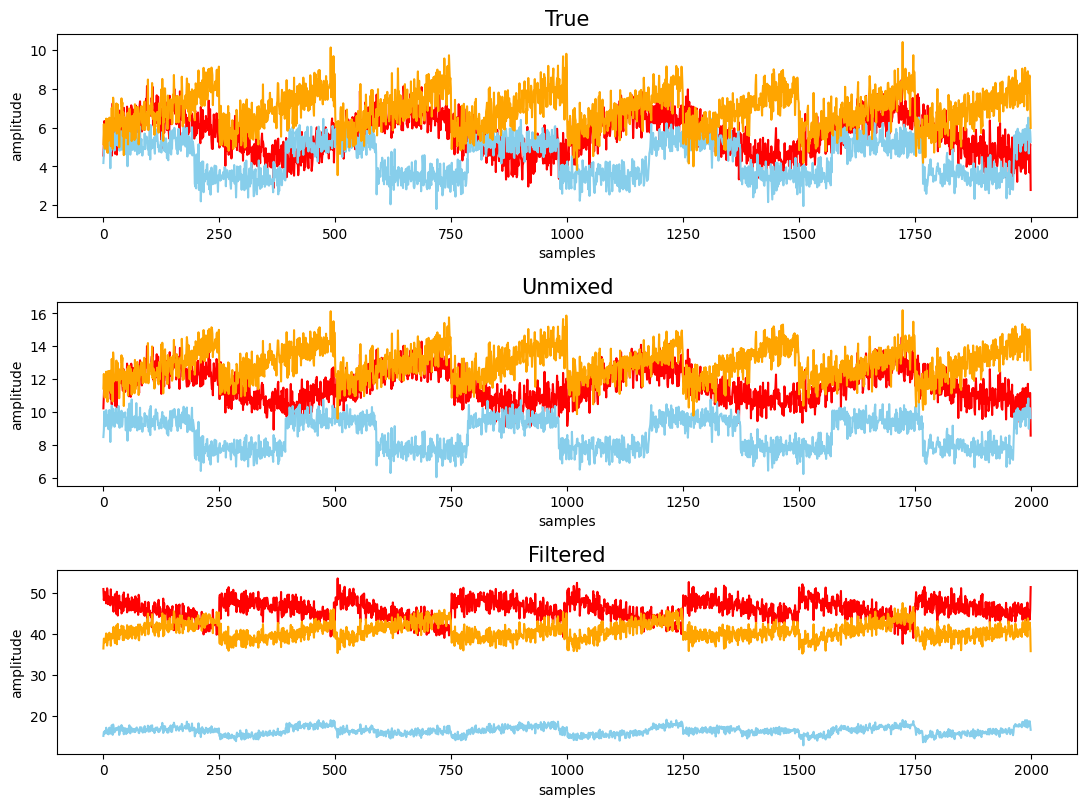

In [50]:
def filter_components(x: np.ndarray, to_keep: list[int]) -> np.ndarray:
    transformer = FastICA(n_components=3, random_state=42)
    transformer.fit(X)

    W = transformer.mixing_
    A = np.linalg.inv(W)

    return X @ A[:, to_keep]
    
visualize_data([S_true, X_unmixed, filter_components(X, [0, 1, 2])], ["True", "Unmixed", "Filtered"])